# Asteroid orbit optimization with PyGMO - Custom Environment
Copyright (c) 2010-2022, Delft University of Technology. All rights reserved. This file is part of the Tudat. Redistribution  and use in source and binary forms, with or without modification, are permitted exclusively under the terms of the Modified BSD license. You should have received a copy of the license with this file. If not, please or visit: http://tudat.tudelft.nl/LICENSE.

## Objectives
The aim of this tutorial is to illustrate the use of PyGMO to optimize an astrodynamics problem simulated with tudatpy. The problem describes the orbit design around a small body; the [Themis asteroid](https://en.wikipedia.org/wiki/25143_Themis). This example consists of three parts that build on each other to ultimately perform an orbit optimization. The three parts are built up as follows: Custom Environment (this page), [Design Space Exploration](aoo_design_space_exploration.ipynb), and [Optimization](aoo_optimization.ipynb).

**This part of the example is focussed on the creation of a custom environment, using manually defined rotation, ephemeris, gravity field, and shape settings**. A PyGMO compatible Problem class is also created for the next parts of the example. Using this problem class, a propagation is conducted to show a possible trajectory orbiting Themis.


### NOTE

It is assumed that the reader of this tutorial is already familiar with the content of [this basic PyGMO tutorial](https://docs.tudat.space/en/latest/_src_advanced_topics/optimization_pygmo.html). The full PyGMO documentation is available [on this website](https://esa.github.io/pygmo2/index.html). Be careful to read the
correct the documentation webpage (there is also a similar one for previous yet now outdated versions [here](https://esa.github.io/pygmo/index.html); as you can see, they can easily be confused).
PyGMO is the Python counterpart of [PAGMO](https://esa.github.io/pagmo2/index.html).

## Import statements
The required import statements are made here, at the very beginning.

Some standard modules are first loaded. These are `os`, `numpy` and `matplotlib.pyplot`.

Then, the different modules of `tudatpy` that will be used are imported.

Finally, in this example, we also need to import the `pygmo` library.

In [1]:
# Load standard modules
import os
import numpy as np
# Uncomment the following to make plots interactive
# %matplotlib widget
from matplotlib import pyplot as plt
from itertools import combinations as comb


# Load tudatpy modules
from tudatpy.data import save2txt
from tudatpy import constants
from tudatpy.interface import spice
from tudatpy.astro import element_conversion
from tudatpy.astro import frame_conversion
from tudatpy.dynamics import environment_setup
from tudatpy.dynamics import propagation_setup
from tudatpy.dynamics import simulator
from tudatpy.util import pareto_optimums

# Load pygmo library
import pygmo as pg

current_dir = os.path.abspath('')

## Creation of Custom Environment

Below a few helper functions are defined that create various custom environment models. These functions are used later in the example to create the simulation


### Themis rotation settings
The first helper function that is setup is `get_Themis_rotation_settings()`. This function can be called to get Themis rotation settings, of type [environment_setup.rotation_model.RotationModelSettings](https://py.api.tudat.space/en/latest/rotation_model.html#tudatpy.dynamics.environment_setup.rotation_model.RotationModelSettings), using a constant angular velocity.

This function only take the name of the body frame of Themis as an input.
In addition, some fixed parameters are defined in this function:

- The orientation of Themis pole, as:
    - The pole declination of -66.3 deg.
    - The pole right ascension 90.53 deg.
    - The meridian fixed at 0 deg.
- The rotation rate of Themis of 712.143 deg/Earth day.

In [2]:
def get_Themis_rotation_settings(Themis_body_frame_name):
    # Definition of initial Themis orientation conditions through the pole orientation
    pole_declination = np.deg2rad(59.8)     # Declination
    pole_right_ascension = np.deg2rad(125.6)  # Right ascension
    meridian_at_epoch = 0.0                   # Meridian

    # Define initial Themis orientation in inertial frame (equatorial plane)
    initial_orientation_j2000 = frame_conversion.inertial_to_body_fixed_rotation_matrix(
        pole_declination, pole_right_ascension, meridian_at_epoch)
    
    # Get initial Themis orientation in inertial frame but in the Ecliptic plane
    initial_orientation_eclipj2000 = np.matmul(spice.compute_rotation_matrix_between_frames(
        "J2000", "ECLIPJ2000", 0.0), initial_orientation_j2000)

    # Manually check the results, if desired
    check_results = False
    if check_results:
        np.set_printoptions(precision=100)
        print(initial_orientation_j2000)
    
        print(initial_orientation_eclipj2000)

    # Compute rotation rate
    # rotation_rate = np.deg2rad(712.143) / constants.JULIAN_DAY
    rotation_period = 8.374187 * 3600.0

    rotation_rate = 2.0 * np.pi / rotation_period

    # Set up rotational model for Themis with constant angular velocity
    return environment_setup.rotation_model.simple(
        "ECLIPJ2000", Themis_body_frame_name, initial_orientation_eclipj2000, 0.0, rotation_rate)

### Themis ephemeris settings
The next helper function defined, `get_Themis_ephemeris_settings()`, that can be used to set the ephemeris of Themis.

The ephemeris for Themis are set using a Keplerian orbit around the Sun. To do this, the initial position at a certain epoch is needed. This position is defined inside the function by the following kepler elements:

- Semi-major axis of $\approx$ 1.324 Astronomical Units ($\approx$ 1.98E+8 km).
- Eccentricity of $\approx$ 0.28.
- Inclination of $\approx$ 1.62 deg.
- Inclination of $\approx$ 1.62 deg.
- Argument of periapsis of $\approx$ 162.8 deg.
- Longitude of ascending node of $\approx$ 69.1 deg.
- Mean anomaly of $\approx$ 187.6 deg.

The only input that this function takes is the gravitational parameter of the Sun, which can be obtained using `spice.get_body_gravitational_parameter("Sun")`.

In [3]:
def get_Themis_ephemeris_settings(sun_gravitational_parameter):
    # Define Themis initial Kepler elements
    Themis_kepler_elements = np.array([
        3.1433 * constants.ASTRONOMICAL_UNIT,
        1.153499536381607E-01,
        np.deg2rad(7.366995500522935E-01),
        np.deg2rad(1.091193307580024E+02),
        np.deg2rad(3.639222711771391E+01),
        np.deg2rad(6.046711080424205E+01)])
    
    # Convert mean anomaly to true anomaly
    Themis_kepler_elements[5] = element_conversion.mean_to_true_anomaly(
        eccentricity=Themis_kepler_elements[1],
        mean_anomaly=Themis_kepler_elements[5])
    
    # Get epoch of initial Kepler elements (in Julian Days) 2025-Dec-12 00:00:00.0000
    kepler_elements_reference_julian_day = 2461021.5
    
    # Sets new reference epoch for Themis ephemerides (different from J2000)
    kepler_elements_reference_epoch = (kepler_elements_reference_julian_day - constants.JULIAN_DAY_ON_J2000) \
                                      * constants.JULIAN_DAY
    
    # Sets the ephemeris model
    return environment_setup.ephemeris.keplerian(
        Themis_kepler_elements,
        kepler_elements_reference_epoch,
        sun_gravitational_parameter,
        "Sun",
        "ECLIPJ2000")

### Themis gravity field settings
The `get_Themis_gravity_field_settings()` helper function can be used to get the gravity field settings of Themis.

It creates a Spherical Harmonics gravity field model expanded up to order 4 and degree 4. Normalized coefficients are hardcoded (see `normalized_cosine_coefficients` and `normalized_sine_coefficients`), as well as the gravitational parameter (2.36). The reference radius and the Themis body fixed frame are to be given as inputs to this function.

In [4]:
def get_Themis_gravity_field_settings(Themis_body_fixed_frame, Themis_radius):
    
    Themis_gravitational_parameter = 3.8e8  # m^3/s^2 — update if you have better value

    # 11x11 matrix → degrees 0-10, orders 0-10
    # Replace these with your actual data
    normalized_cosine_coefficients = np.array([
        [1.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=0
        [4.00437049323391e-10,      -2.00118621702933e-10,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=1
        [-0.0311484302600628, -0.00247282373836691,   -0.00274461339769334,  0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=2
        [-0.00200571383331492, -0.000432075164317321, 0.00194227892499834,0.00137270957639051, 0.0,    0.0,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=3
        [0.00285332640564815,  0.00110182963502399, -0.000735718367676304, 0.000724745021813717, 0.00176998960899976, 0.0,   0.0,      0.0,      0.0,      0.0,      0.0],   # n=4
        [0.000830075337320937,      0.000287519798138761,      -0.000528107896235689,      -0.000867730821110781,      4.79023000648861e-05,      0.000879439295195050,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=5  ← your data
        [-0.000675558666706258,     -0.000205585971704600,      -0.000221135345635429,     -0.000318618655804238,      -0.000888434175048908,      -8.73422067817230e-05,     -0.000661361102590928,      0.0,      0.0,      0.0,      0.0],   # n=6
        [-0.000248341594690701,      -0.000163829109924533,      0.000232085380551457,      0.000258506065235110,      0.000160180230193337,      -0.000286377268939702,      6.77821275261500e-05,     0.000157407479968084,      0.0,      0.0,      0.0],   # n=7
        [0.000335217568650732,      -2.55140470111988e-05,      0.000274255269526383,      4.96324094064370e-05,      0.000342523466493208,     -1.86321450442635e-05,      0.000172675634502437,     9.50587862238274e-05,      0.000145987430976338,      0.0,      0.0],   # n=8
        [6.99720204690460e-05,      8.60097640010565e-05,      -0.000102732485716739,      -4.39268805337316e-05,      -0.000102645709362265,      0.000116936443373915,      -6.33826315277080e-05,      -5.20516633544555e-05,     -3.74472817959948e-05,      2.61212670888696e-05,      0.0],   # n=9
        [-0.000144111884090325,      2.32066521881085e-05,      -0.000126297847367392,      -2.62937726762541e-05,      -0.000124821278562081,      1.97212481561922e-05,      -4.97665457889904e-05,      -3.59202127991231e-05,      -7.28226920211166e-05,      1.23255404885492e-06,      -8.44844997134115e-05],   # n=10
    ])

    normalized_sine_coefficients = np.array([
        # m=0          m=1                        m=2                       m=3                       m=4                       m=5                       m=6                       m=7                       m=8                       m=9                       m=10
        [ 0.0,         0.0,                       0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=0
        [ 0.0,        -1.12918257515491e-09,       0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=1
        [ 0.0,         0.00107223359971325,       -0.00332663415194219,      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=2
        [ 0.0,        -0.00907886970678376,       -0.000235642226308041,    -0.00453797805800339,       0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=3
        [ 0.0,        -0.000236332856522398,       0.000679356889179597,     0.00103902654905862,      -0.00164525397614147,      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=4
        [ 0.0,         0.00311673748224299,       -0.000197902324683847,     0.000723574770295993,     7.12712231701076e-05,      0.000728705277735932,      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=5
        [ 0.0,         9.08985833204355e-05,      -7.81012920836034e-05,    -0.000382933168574949,     0.000417670991355626,     -0.000244616302121161,     -0.000272475519450808,     0.0,                      0.0,                      0.0,                      0.0         ],  # n=6
        [ 0.0,        -0.000726023965052120,      -0.000157289026194778,    -0.000151049434293496,    -1.31229025167918e-05,     -0.000180291881759017,      4.75861083370220e-05,     -0.000466425371326853,     0.0,                      0.0,                      0.0         ],  # n=7
        [ 0.0,        -4.66199482564515e-05,       4.07552978692181e-05,     0.000141144082038173,    -7.01025270851237e-05,      3.48820998708198e-05,      9.78492071833127e-05,      2.78823107064210e-05,     -0.000108013182515871,     0.0,                      0.0         ],  # n=8
        [ 0.0,         0.000177445235331498,       0.000124031343956387,     0.000102169331575207,     3.03402767376233e-05,      0.000131791270134196,      1.21961070494812e-05,      0.000178265283377157,      3.51673248637755e-05,      4.88474288152410e-05,     0.0         ],  # n=9
        [ 0.0,         7.90100853753287e-06,      -1.42280089749264e-05,    -7.29562295080795e-05,     2.77916592967652e-06,     -2.60570209403151e-05,     -2.33055610543032e-05,     -2.66308045112190e-05,      2.55117509946166e-05,     -3.32601179349906e-05,    -3.94450492257997e-06],  # n=10
    ])
    # ← UNCOMMENT this and remove the central() call below
    return environment_setup.gravity_field.spherical_harmonic(
        gravitational_parameter=Themis_gravitational_parameter,
        reference_radius=Themis_radius,
        normalized_cosine_coefficients=normalized_cosine_coefficients,
        normalized_sine_coefficients=normalized_sine_coefficients,
        associated_reference_frame=Themis_body_fixed_frame)

    # ← REMOVE this line (was placeholder, ignores all SH structure)
    # return environment_setup.gravity_field.central(
    #     gravitational_parameter=Themis_gravitational_parameter)

### Themis shape settings
The next helper function defined, `get_Themis_shape_settings()` return the shape settings object for Themis. It uses a simple spherical model, and take the radius of Themis as input.

In [5]:
def get_Themis_shape_settings(Themis_radius):
    # Creates spherical shape settings
    return environment_setup.shape.spherical(Themis_radius)

### Simulation bodies
Next, the `create_simulation_bodies()` function is setup, that returns an [environment.SystemOfBodies](https://py.api.tudat.space/en/latest/environment.html#tudatpy.dynamics.environment.SystemOfBodies) object. This object contains all the body settings and body objects required by the simulation. Only one input is required to this function: the radius of Themis.

Moreover, in the system of bodies that is returned, a `Spacecraft` body is included, with a mass of 400kg, and a radiation pressure interface. This body is the one for which an orbit is to be optimised around Themis.

In [6]:
def create_simulation_bodies(Themis_radius):
    ### CELESTIAL BODIES ###
    # Define Themis body frame name
    Themis_body_frame_name = "Themis_Frame"

    # Create default body settings for selected celestial bodies
    bodies_to_create = ["Sun", "Earth", "Jupiter", "Saturn", "Mars"]

    # Create default body settings for bodies_to_create, with "Earth"/"J2000" as
    # global frame origin and orientation. This environment will only be valid
    # in the indicated time range [simulation_start_epoch --- simulation_end_epoch]
    body_settings = environment_setup.get_default_body_settings(
        bodies_to_create,
        "SSB",
        "ECLIPJ2000")

    # Add Themis body
    body_settings.add_empty_settings("Themis")

    # Adds Themis settings
    # Gravity field
    body_settings.get("Themis").gravity_field_settings = get_Themis_gravity_field_settings(Themis_body_frame_name,
                                                                        Themis_radius)
    # Rotational model
    body_settings.get("Themis").rotation_model_settings = get_Themis_rotation_settings(Themis_body_frame_name)
    # Ephemeris
    body_settings.get("Themis").ephemeris_settings = get_Themis_ephemeris_settings(
        spice.get_body_gravitational_parameter( 'Sun') )
    # Shape (spherical)
    body_settings.get("Themis").shape_settings = get_Themis_shape_settings(Themis_radius)

    ### VEHICLE BODY ###
    # Create vehicle object
    body_settings.add_empty_settings("Spacecraft")
    body_settings.get("Spacecraft").constant_mass = 986 # mass latest

    # Create radiation pressure settings
    reference_area_radiation = 65+2.4*2.2  # talked with structure team
    radiation_pressure_coefficient = 1.2
    occulting_bodies_dict = dict()
    occulting_bodies_dict["Sun"] = ["Themis"]
    vehicle_target_settings = environment_setup.radiation_pressure.cannonball_radiation_target(
        reference_area_radiation, radiation_pressure_coefficient, occulting_bodies_dict )

    # Add the radiation pressure interface to the body settings
    body_settings.get("Spacecraft").radiation_pressure_target_settings = vehicle_target_settings

    # Create system of selected bodies
    bodies = environment_setup.create_system_of_bodies(body_settings)

    return bodies

### Acceleration models
The `get_acceleration_models()` helper function returns the acceleration models to be used during the astrodynamic simulation. The following accelerations are included:

- Gravitational acceleration modelled as a Point Mass from the Sun, Jupiter, Saturn, Mars, and the Earth.
- Gravitational acceleration modelled as Spherical Harmonics up to degree and order 4 from Themis.
- Radiation pressure from the Sun using a simplified cannonball model.

This function takes as input the list of bodies that will be propagated, the list of central bodies related to the propagated bodies, and the system of bodies used.

In [7]:
def get_acceleration_models(bodies_to_propagate, central_bodies, bodies):
    # Define accelerations acting on Spacecraft
    accelerations_settings_spacecraft = dict(
        Sun =     [ propagation_setup.acceleration.radiation_pressure(),
                    propagation_setup.acceleration.point_mass_gravity() ],
        Themis = [ propagation_setup.acceleration.spherical_harmonic_gravity(10, 10) ],
        Jupiter = [ propagation_setup.acceleration.point_mass_gravity() ],
        Saturn =  [ propagation_setup.acceleration.point_mass_gravity() ],
        Mars =    [ propagation_setup.acceleration.point_mass_gravity() ],
        Earth =   [ propagation_setup.acceleration.point_mass_gravity() ]
    )

    # Create global accelerations settings dictionary
    acceleration_settings = {"Spacecraft": accelerations_settings_spacecraft}

    # Create acceleration models
    return propagation_setup.create_acceleration_models(
        bodies,
        acceleration_settings,
        bodies_to_propagate,
        central_bodies)

### Termination settings
The termination settings for the simulation are defined by the `get_termination_settings()` helper.

Nominally, the simulation terminates when a final epoch is reached. However, this can happen in advance if the
spacecraft breaks out of the predefined altitude range.
This is defined by the four inputs that this helper function takes, related to the mission timing and the mission altitude range.

In [8]:
def get_termination_settings(mission_initial_time, 
                             mission_duration,
                             minimum_distance_from_com,
                             maximum_distance_from_com):
    # Mission duration
    time_termination_settings = propagation_setup.propagator.time_termination(
        mission_initial_time + mission_duration,
        terminate_exactly_on_final_condition=False
    )
    # Upper altitude
    upper_altitude_termination_settings = propagation_setup.propagator.dependent_variable_termination(
        dependent_variable_settings=propagation_setup.dependent_variable.relative_distance('Spacecraft', 'Themis'),
        limit_value=maximum_distance_from_com,
        use_as_lower_limit=False,
        terminate_exactly_on_final_condition=False
    )
    # Lower altitude
    lower_altitude_termination_settings = propagation_setup.propagator.dependent_variable_termination(
        dependent_variable_settings=propagation_setup.dependent_variable.relative_distance('Spacecraft', 'Themis'),
        limit_value=minimum_distance_from_com,
        use_as_lower_limit=True,
        terminate_exactly_on_final_condition=False
    )

    # Define list of termination settings
    termination_settings_list = [time_termination_settings,
                                 upper_altitude_termination_settings,
                                 lower_altitude_termination_settings]

    return propagation_setup.propagator.hybrid_termination(termination_settings_list,
                                                           fulfill_single_condition=True)

### Dependent variables to save
Finally, the `get_dependent_variables_to_save()` helper function returns a pre-defined list of dependent variables to save during the propagation, alongside the propagated state. This function can be expanded, but contains by default only the position of the spacecraft with respect to the Themis asteroid expressed in spherical coordinates.

In [9]:
def get_dependent_variables_to_save():
    dependent_variables_to_save = [
        propagation_setup.dependent_variable.central_body_fixed_spherical_position(
            "Spacecraft", "Themis"
        )
    ]
    return dependent_variables_to_save

## Optimisation problem formulation 
The optimisation problem can now be defined. This has to be done in a class that is compatible to what the PyGMO library can expect from this User Defined Problem (UDP). See [this page](https://esa.github.io/pygmo2/problem.html#pygmo.problem) from the PyGMO documentation as a reference. In this example, this class is called `AsteroidOrbitProblem`.

The `AsteroidOrbitProblem.__init__()` method is used to setup the problem. Most importantly, many problem-related objects are saved through it: the system of bodies, the propagator settings, the parameters that will later be used for the termination settings, and the design variables boundaries. The input arguments that refer to functions are defined using a lambda function. While this seems unnecessary, it is **essential**: PyGMO internally pickles its user defined objects and some objects including the ones here cannot be pickled properly without using lambda functions.

Then, the `AsteroidOrbitProblem.get_bounds()` function is used by PyGMO to define the search space. This function returns the boundaries of each design variable, as defined in the [pygmo.problem.get_bounds](https://esa.github.io/pygmo2/problem.html#pygmo.problem.get_bounds) documentation.

The `AsteroidOrbitProblem.get_nobj()` function is also used by PyGMO. It returns the number of objectives in the problem, in this case 2.

The last function used by PyGMO is `AsteroidOrbitProblem.fitness()`. As mentioned in the [pygmo.problem.fitness](https://esa.github.io/pygmo2/problem.html#pygmo.problem.fitness) documentation, PyGMO will input a given set of design variable to this function, that is expected to return a score associated with them. This is thus the cost function of the problem. In this case, this `AsteroidOrbitProblem.fitness()` runs a simulation using TudatPy based on the orbital elements that PyGMO inputs as design variables. Then, the score relative to the two optimisation objectives is computed and returned. Note that, in PyGMO, this fitness function will always be **minimised**. To **maximise** objectives instead, the fitness that is returned will have to be for instance inversed. This is why, because we want to maximise the coverage, the fitness for this objective is computed as the inverse of the mean latitudes. If the mean of the latitudes is high, the coverage is high, which is closer to the optimum. Because this better value is higher than worse values, we return the fitness as the inverse of the mean latitudes.

One more function is included, `AsteroidOrbitProblem.get_last_run_dynamics_simulator()`. This allows to get the dynamic simulator of the last simulation that was run in the problem.

In [10]:
class AsteroidOrbitProblem:
    
    def __init__(self,
                 bodies,
                 propagator_settings,
                 mission_initial_time,
                 mission_duration,
                 design_variable_lower_boundaries,
                 design_variable_upper_boundaries):
        
        # Sets input arguments as lambda function attributes
        # NOTE: this is done so that the class is "pickable", i.e., can be serialized by pygmo
        self.bodies_function = lambda: bodies
        self.propagator_settings_function = lambda: propagator_settings
        
        # Initialize empty dynamics simulator
        self.dynamics_simulator_function = lambda: None
        
        # Set other input arguments as regular attributes
        self.mission_initial_time = mission_initial_time
        self.mission_duration = mission_duration
        self.mission_final_time = mission_initial_time + mission_duration
        self.design_variable_lower_boundaries = design_variable_lower_boundaries
        self.design_variable_upper_boundaries = design_variable_upper_boundaries

    def get_bounds(self):
        return (list(self.design_variable_lower_boundaries), list(self.design_variable_upper_boundaries))

    def get_nobj(self):
        return 2

    def fitness(self,
                orbit_parameters):
        # Retrieves system of bodies
        current_bodies = self.bodies_function()
        
        # Retrieves Themis gravitational parameter
        Themis_gravitational_parameter = current_bodies.get("Themis").gravitational_parameter
        
        # Reset the initial state from the design variable vector
        new_initial_state = element_conversion.keplerian_to_cartesian_elementwise(
            gravitational_parameter=Themis_gravitational_parameter,
            semi_major_axis=orbit_parameters[0],
            eccentricity=orbit_parameters[1],
            inclination=np.deg2rad(orbit_parameters[2]),
            argument_of_periapsis=np.deg2rad(235.7),
            longitude_of_ascending_node=np.deg2rad(orbit_parameters[3]),
            true_anomaly=np.deg2rad(139.87))
        
        # Retrieves propagator settings object
        propagator_settings = self.propagator_settings_function()
        
        # Reset the initial state
        propagator_settings.initial_states = new_initial_state

        # Propagate orbit
        dynamics_simulator = simulator.create_dynamics_simulator(current_bodies,
                                                                        propagator_settings)
        # Update dynamics simulator function
        self.dynamics_simulator_function = lambda: dynamics_simulator
       
        # --- DEBUG BLOCK START ---
        state_hist = dynamics_simulator.propagation_results.state_history
        dep_var_hist = dynamics_simulator.propagation_results.dependent_variable_history

        print(f"\n{'='*50}")
        print(f"[DEBUG] Orbit params: a={orbit_parameters[0]:.1f} m, e={orbit_parameters[1]:.4f}, "
              f"i={orbit_parameters[2]:.2f} deg, RAAN={orbit_parameters[3]:.2f} deg")

        print(f"[DEBUG] Propagation steps recorded: {len(state_hist)}")

        if len(state_hist) > 0:
            t_start = min(state_hist.keys())
            t_end   = max(state_hist.keys())
            duration_achieved = t_end - t_start
            print(f"[DEBUG] Time propagated: {duration_achieved:.2f} s  "
                  f"({duration_achieved / 86400:.4f} days)")
            print(f"[DEBUG] Mission duration target: {self.mission_duration / 86400:.2f} days")

            if duration_achieved < self.mission_duration * 0.999:
                # Terminated early — figure out why
                if len(dep_var_hist) > 0:
                    dep_arr = np.vstack(list(dep_var_hist.values()))
                    final_distance = dep_arr[-1, 0]   # relative distance [m]
                    final_altitude = final_distance - 99_000.0  # rough surface altitude

                    print(f"[DEBUG] *** EARLY TERMINATION ***")
                    print(f"[DEBUG]   Final distance from CoM : {final_distance:.2f} m  ({final_distance/1000:.3f} km)")
                    print(f"[DEBUG]   Final altitude (approx) : {final_altitude:.2f} m  ({final_altitude/1000:.3f} km)")

                    if final_distance < self.mission_duration:   # placeholder — check your min
                        print(f"[DEBUG]   → CRASHED (below minimum distance)")
                    elif final_distance > 649_000:
                        print(f"[DEBUG]   → ESCAPED (above maximum distance)")
                    else:
                        print(f"[DEBUG]   → Reason unclear; check termination_details below")
                else:
                    print(f"[DEBUG]   *** dep_var_hist is EMPTY — likely terminated in step 1 ***")
            else:
                print(f"[DEBUG] Full mission duration completed ✓")
        else:
            print(f"[DEBUG] *** state_history is EMPTY — propagation failed at t=0 ***")

        # Termination details (tudat exposes this)
        try:
            term = dynamics_simulator.propagation_results.termination_details
            print(f"[DEBUG] Termination details: {term}")
        except Exception as ex:
            print(f"[DEBUG] Could not retrieve termination_details: {ex}")

        print(f"{'='*50}\n")
    # --- DEBUG BLOCK END ---
        # Retrieve dependent variable history
        dependent_variables = dynamics_simulator.propagation_results.dependent_variable_history
        dependent_variables_list = np.vstack(list(dependent_variables.values()))
        
        # Retrieve distance
        distance = dependent_variables_list[:, 0]
        # Retrieve latitude
        latitudes = dependent_variables_list[:, 1]
        
        # Compute mean latitude
        mean_latitude = np.mean(np.absolute(latitudes))
        # Computes fitness as mean latitude
        current_fitness = 1.0 / mean_latitude

        # Exaggerate fitness value if the spacecraft has broken out of the selected distance range
        current_penalty = 0.0
        if (max(dynamics_simulator.propagation_results.dependent_variable_history.keys()) < self.mission_final_time):
            current_penalty = 1.0E2

        return [current_fitness + current_penalty, np.mean(distance) + current_penalty * 1.0E3]

    def get_last_run_dynamics_simulator(self):
        return self.dynamics_simulator_function()

### Setup orbital simulation
Before running the optimisation, some aspect of the orbital simulation around Themis still need to be setup.
Most importantly, the simulation bodies, acceleration models, integrator settings, and propagator settings, all have to be defined. To do so, the helpers that were defined above are used.

#### Simulation settings
The simulation settings are first defined.

The SPICE kernels are loaded, so that we can access the gravitational parameter of the Sun in the `create_simulation_bodies()` function.

The definition of the termination parameters follows, with a maximum mission duration of 5 Earth days. The altitude range above Themis is also defined between 150 meters and 5 km.

Follows the definition of the design variable range, that PyGMO will use during the optimisation. This range is as follows:

- Initial semi-major axis between 300 and 2000 meters.
- Initial eccentricity between 0 and 0.3.
- Initial inclination between 0 and 180 deg.
- Initial longitude of the ascending node between 0 and 360 deg.
 
The system of bodies is then setup using the `create_simulation_bodies()` helper, and a radius for Themis of 161.915 meters.

Finally, the acceleration models are setup using the `get_acceleration_models()` helper.

In [11]:
# Load spice kernels
spice.load_standard_kernels()

# Set simulation start and end epochs
# mission_initial_time = 0.0
from tudatpy.astro.time_representation import DateTime

mission_initial_time = DateTime(
    2041, 12, 12, 19, 23, 12
).epoch()
mission_duration = 100.0 * constants.JULIAN_DAY

# Define Themis radius
Themis_radius = 99*1000

# Set altitude termination conditions
minimum_distance_from_com = 10.0E3 + Themis_radius
maximum_distance_from_com = 550.0E3 + Themis_radius

# Set boundaries on the design variables
design_variable_lb = (5000.0, 0.0, 0.0, 0.0)
design_variable_ub = (550000.0, 0.3, 180, 360)

# Create simulation bodies
bodies = create_simulation_bodies(Themis_radius)

# Define bodies to propagate and central bodies
bodies_to_propagate = ["Spacecraft"]
central_bodies = ["Themis"]

# Create acceleration models
acceleration_models = get_acceleration_models(bodies_to_propagate, central_bodies, bodies)

#### Dependent variables, termination settings, and orbit parameters
To define the propagator settings in the subsequent sections, we first call the `get_dependent_variables_to_save()` and `get_termination_settings()` helpers to define the dependent variables and termination settings.

The `orbit_parameters` list is defined from a `final_population.dat` file from the optimization. These values are not crucial, but do help for a 'relatively' stable orbit.

In [12]:
# Define list of dependent variables to save
dependent_variables_to_save = get_dependent_variables_to_save()

# Create propagation settings
termination_settings = get_termination_settings(
    mission_initial_time, mission_duration, minimum_distance_from_com, maximum_distance_from_com)

orbit_parameters = [1.20940330e+03, 2.61526215e-01, 7.53126558e+01, 2.60280587e+02]

#### Integrator and Propagator settings
Let's now define the integrator settings. In this case, a variable step integration scheme is used, with the followings:

- RKF7(8) coefficient set.
- Initial time step of 1 sec.
- Minimum and maximum time steps of 1E-6 sec and 1 Earth day.
- Relative and absolute error tolerances of 1E-8.

Then, we define pure translational propagation settings with a Cowell propagator. The initial state is set to 0 for both the position and the velocity. This is because the initial state will later be changed in the `AsteroidOrbitProblem.fitness()` function during the optimisation.

In [13]:
# Create numerical integrator settings
integrator_settings = propagation_setup.integrator.runge_kutta_variable_step_size(
    initial_time_step=1.0,
    coefficient_set=propagation_setup.integrator.CoefficientSets.rkf_78,
    minimum_step_size=1.0E-6,
    maximum_step_size=constants.JULIAN_DAY,
    relative_error_tolerance=1.0E-8,
    absolute_error_tolerance=1.0E-8)

# Get current propagator, and define translational state propagation settings
propagator = propagation_setup.propagator.cowell
# Define propagation settings
initial_state = np.zeros(6)
propagator_settings = propagation_setup.propagator.translational(central_bodies,
                                                                         acceleration_models,
                                                                         bodies_to_propagate,
                                                                         initial_state,
                                                                         mission_initial_time,
                                                                         integrator_settings,
                                                                         termination_settings,
                                                                         propagator,
                                                                         dependent_variables_to_save)

## Propagating Orbit

To finalise this part of the example, a simple orbit is propagated to show the plausibility of the simulation. The PyGMO compatible problem class is created, after which the fitness function is called which creates the dynamics simulator and subsequently returns the data that can be used for post-processing.

The 4 design variables are:

- initial values of the semi-major axis.
- initial eccentricity.
- initial inclination.
- initial longitude of the ascending node.

In [14]:
orbitProblem = AsteroidOrbitProblem(bodies,
                                    propagator_settings,
                                    mission_initial_time,
                                    mission_duration,
                                    design_variable_lb,
                                    design_variable_ub)
# design_variable_vector = np.array([1.20940330e+03, 2.61526215e-01, 7.53126558e+01, 2.60280587e+02])
design_variable_vector = np.array([
    179788.0,
    0.00023,
    127.49,
    74.09
])
orbitProblem.fitness(design_variable_vector)


[DEBUG] Orbit params: a=179788.0 m, e=0.0002, i=127.49 deg, RAAN=74.09 deg
[DEBUG] Propagation steps recorded: 8908
[DEBUG] Time propagated: 8640812.43 s  (100.0094 days)
[DEBUG] Mission duration target: 100.00 days
[DEBUG] Full mission duration completed ✓
[DEBUG] Termination details: <tudatpy.kernel.dynamics.propagation.PropagationTerminationDetailsFromHybridCondition object at 0x000001F7C8BD67F0>



[2.9784111205770505, 177904.14004360168]

### Visualizing orbit
With a little bit of post-processing, the orbit can be plotted. You can see that with only 2 full orbits that the trajectory is already very perturbed. This has to do with all the perturbations that are in the model, which poses a challenge for the optimization in the next two parts of the example.

[PLOT DEBUG] state_history has 8908 entries
[PLOT DEBUG] Position range X: [-181444, 178411] m
[PLOT DEBUG] Position range Y: [-174857, 180061] m
[PLOT DEBUG] Position range Z: [-176437, 181428] m


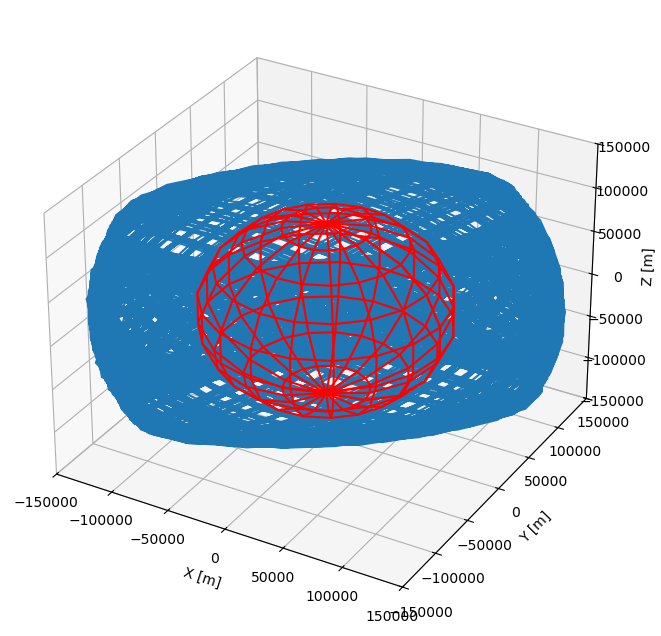

In [15]:
state_history = orbitProblem.get_last_run_dynamics_simulator().propagation_results.state_history

print(f"[PLOT DEBUG] state_history has {len(state_history)} entries")

if len(state_history) < 2:
    print("[PLOT DEBUG] *** Too few points to plot — check termination bug above ***")
else:
    state_history_arr = np.vstack(list(state_history.values()))
    print(f"[PLOT DEBUG] Position range X: [{state_history_arr[:,0].min():.0f}, {state_history_arr[:,0].max():.0f}] m")
    print(f"[PLOT DEBUG] Position range Y: [{state_history_arr[:,1].min():.0f}, {state_history_arr[:,1].max():.0f}] m")
    print(f"[PLOT DEBUG] Position range Z: [{state_history_arr[:,2].min():.0f}, {state_history_arr[:,2].max():.0f}] m")

    # ... your existing plot code ...

state_history = orbitProblem.get_last_run_dynamics_simulator().propagation_results.state_history
state_history = np.vstack(list(state_history.values()))
state_history = np.vstack(state_history)

fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot(1, 1, 1, projection='3d')

u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
x = Themis_radius * np.cos(u)*np.sin(v)
y = Themis_radius * np.sin(u)*np.sin(v)
z = Themis_radius * np.cos(v)
ax.plot_wireframe(x, y, z, color="red")

ax.plot(state_history[:, 0], state_history[:, 1], state_history[:, 2])
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_zlabel('Z [m]')
ax.set_xlim([-150000,150000])
ax.set_ylim([-150000,150000])
ax.set_zlim([-150000,150000])
ax.grid()



In [16]:
import csv
import os

# ── 1. Pull state history from the last run ──────────────────────────────────
state_history = orbitProblem.get_last_run_dynamics_simulator()\
                            .propagation_results.state_history

# ── 2. Define output path  (raw string → backslashes are safe) ───────────────
output_path = r"D:\CALTECH_MS_SPACE_ENGINEERING\105c\themis_trajectory.csv"

# ── 3. Verify the folder exists before writing ───────────────────────────────
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# ── 4. Write X, Y, Z to CSV ──────────────────────────────────────────────────
if len(state_history) < 2:
    print("[SAVE] state_history has fewer than 2 points — nothing to save.")
    print("       Fix the termination bug first (see Bug #1).")
else:
    with open(output_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["time_s", "x_m", "y_m", "z_m","v_x","v_y","v_z"])
        for t, state in state_history.items():
            writer.writerow([t, state[0], state[1], state[2], state[3], state[4], state[5]])

    print(f"[SAVE] Saved {len(state_history)} points → {output_path}")

[SAVE] Saved 8908 points → D:\CALTECH_MS_SPACE_ENGINEERING\105c\themis_trajectory.csv


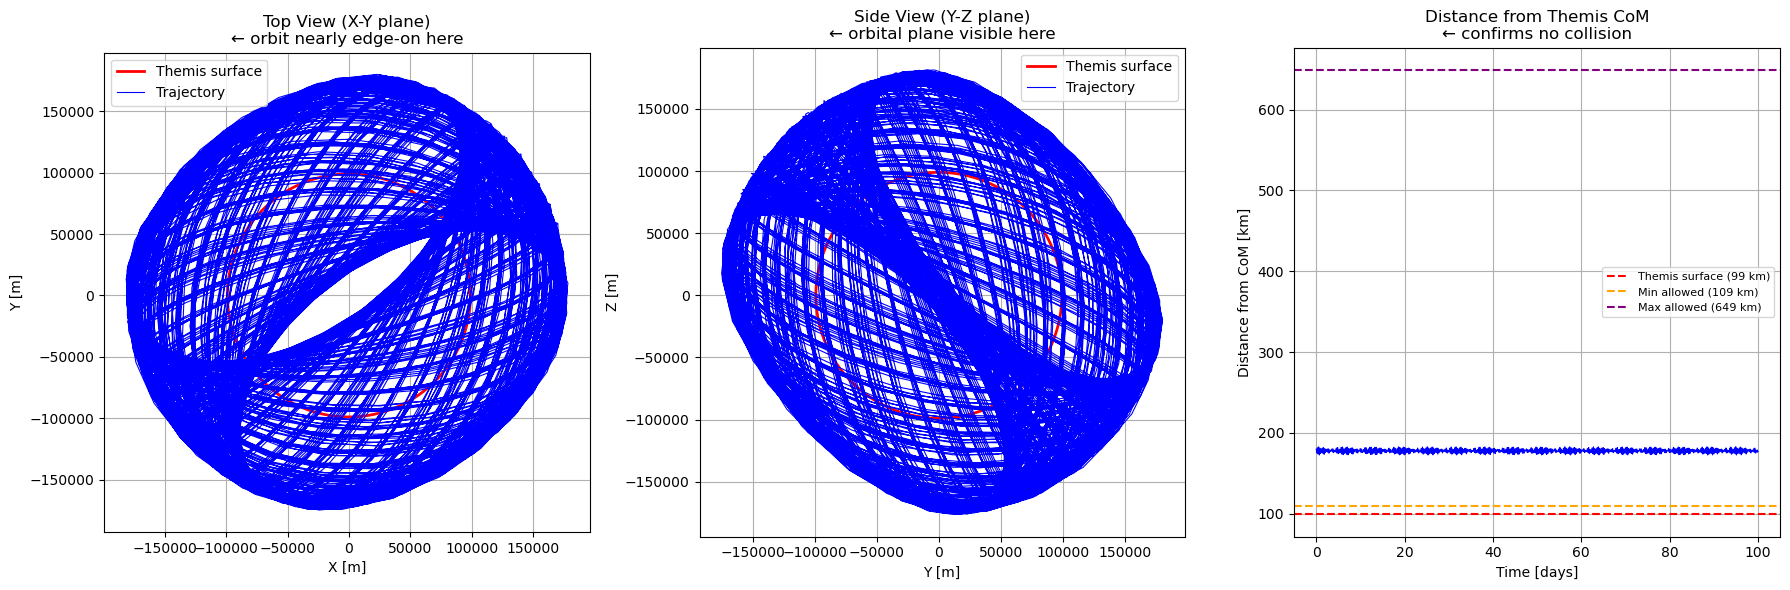

Periapsis distance:   172.59 km
Apoapsis distance:    182.85 km
Themis radius:        99.00 km
Min allowed distance: 109.00 km
Margin at periapsis:  63.59 km above limit


In [17]:
state_history = orbitProblem.get_last_run_dynamics_simulator()\
    .propagation_results.state_history
state_history_arr = np.vstack(list(state_history.values()))

x = state_history_arr[:, 0]
y = state_history_arr[:, 1]
z = state_history_arr[:, 2]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Top view: X-Y plane ---
ax1 = axes[0]
theta = np.linspace(0, 2*np.pi, 200)
ax1.plot(Themis_radius * np.cos(theta), Themis_radius * np.sin(theta),
         'r-', linewidth=2, label='Themis surface')
ax1.plot(x, y, 'b-', linewidth=0.8, label='Trajectory')
ax1.set_xlabel('X [m]')
ax1.set_ylabel('Y [m]')
ax1.set_title('Top View (X-Y plane)\n← orbit nearly edge-on here')
ax1.set_aspect('equal')
ax1.legend()
ax1.grid(True)

# --- Side view: Y-Z plane ---
ax2 = axes[1]
ax2.plot(Themis_radius * np.cos(theta), Themis_radius * np.sin(theta),
         'r-', linewidth=2, label='Themis surface')
ax2.plot(y, z, 'b-', linewidth=0.8, label='Trajectory')
ax2.set_xlabel('Y [m]')
ax2.set_ylabel('Z [m]')
ax2.set_title('Side View (Y-Z plane)\n← orbital plane visible here')
ax2.set_aspect('equal')
ax2.legend()
ax2.grid(True)

# --- Distance from CoM over time ---
ax3 = axes[2]
times = np.array(list(orbitProblem.get_last_run_dynamics_simulator()
                       .propagation_results.state_history.keys()))
distance_from_com = np.sqrt(x**2 + y**2 + z**2)
ax3.plot((times - times[0]) / 86400, distance_from_com / 1000, 'b-', linewidth=0.8)
ax3.axhline(99, color='red', linestyle='--', label='Themis surface (99 km)')
ax3.axhline(109, color='orange', linestyle='--', label='Min allowed (109 km)')
ax3.axhline(649, color='purple', linestyle='--', label='Max allowed (649 km)')
ax3.set_xlabel('Time [days]')
ax3.set_ylabel('Distance from CoM [km]')
ax3.set_title('Distance from Themis CoM\n← confirms no collision')
ax3.legend(fontsize=8)
ax3.grid(True)

plt.tight_layout()
plt.savefig('orbit_views.png', dpi=150)
plt.show()

# Quick sanity print
print(f"Periapsis distance:   {distance_from_com.min()/1000:.2f} km")
print(f"Apoapsis distance:    {distance_from_com.max()/1000:.2f} km")
print(f"Themis radius:        {Themis_radius/1000:.2f} km")
print(f"Min allowed distance: {minimum_distance_from_com/1000:.2f} km")
print(f"Margin at periapsis:  {(distance_from_com.min() - minimum_distance_from_com)/1000:.2f} km above limit")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# ── 1. Pull data ──────────────────────────────────────────────────────────────
state_history = orbitProblem.get_last_run_dynamics_simulator() \
                            .propagation_results.state_history

times_raw  = np.array(list(state_history.keys()))
states_arr = np.vstack(list(state_history.values()))

x = states_arr[:, 0]
y = states_arr[:, 1]
z = states_arr[:, 2]
distance_from_com = np.sqrt(x**2 + y**2 + z**2)

total_points = len(times_raw)
print(f"Total propagation points: {total_points}")
print(f"Mission duration: {(times_raw[-1]-times_raw[0])/86400:.1f} days")

# ── 2. Downsample for smooth animation ───────────────────────────────────────
# Target ~400 frames → good balance of smoothness vs file size
# ── Change these 3 values ──────────────────────────────────────────
N_FRAMES  = 7200       # was 400 → more frames = smoother motion
TRAIL_LEN = 100        # was 60  → slightly longer trail looks fluid

step     = max(1, total_points // N_FRAMES)
idx      = np.arange(0, total_points, step)

x_anim    = x[idx]
y_anim    = y[idx]
z_anim    = z[idx]
times_anim = times_raw[idx]
dist_anim  = distance_from_com[idx]

# Trail length: how many past frames to show as fading trail


print(f"Animation frames: {len(idx)}, trail length: {TRAIL_LEN} frames")

# ── 3. Build Themis sphere ────────────────────────────────────────────────────
u_sph, v_sph = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
sx = Themis_radius * np.cos(u_sph) * np.sin(v_sph)
sy = Themis_radius * np.sin(u_sph) * np.sin(v_sph)
sz = Themis_radius * np.cos(v_sph)

# ── 4. Figure setup ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 7), facecolor='#0a0a1a')
fig.suptitle('Spacecraft Orbiting Themis  |  10×10 Spherical Harmonics Gravity',
             color='white', fontsize=12, y=0.98)

# Left: 3D orbit view
ax3d = fig.add_subplot(1, 2, 1, projection='3d')
ax3d.set_facecolor('#0a0a1a')
ax3d.xaxis.pane.fill = False
ax3d.yaxis.pane.fill = False
ax3d.zaxis.pane.fill = False
ax3d.xaxis.pane.set_edgecolor('#222244')
ax3d.yaxis.pane.set_edgecolor('#222244')
ax3d.zaxis.pane.set_edgecolor('#222244')
ax3d.tick_params(colors='#aaaacc', labelsize=7)
ax3d.xaxis.label.set_color('#aaaacc')
ax3d.yaxis.label.set_color('#aaaacc')
ax3d.zaxis.label.set_color('#aaaacc')

PLOT_LIM = 230_000
ax3d.set_xlim(-PLOT_LIM, PLOT_LIM)
ax3d.set_ylim(-PLOT_LIM, PLOT_LIM)
ax3d.set_zlim(-PLOT_LIM, PLOT_LIM)
ax3d.set_xlabel('X [m]', labelpad=2)
ax3d.set_ylabel('Y [m]', labelpad=2)
ax3d.set_zlabel('Z [m]', labelpad=2)
ax3d.set_title('3D Trajectory', color='white', fontsize=10, pad=4)

# Themis sphere (static)
ax3d.plot_surface(sx, sy, sz, color='#cc4422', alpha=0.55, linewidth=0)
ax3d.plot_wireframe(sx, sy, sz, color='#ff6644', alpha=0.20,
                    rstride=3, cstride=3, linewidth=0.4)

# Ghost of full orbit (very faint)
ax3d.plot(x, y, z, color='#3333aa', alpha=0.08, linewidth=0.4)

# Trail and satellite dot (will be updated)
trail_line,  = ax3d.plot([], [], [], color='#4488ff', linewidth=1.2, alpha=0.9)
sat_dot,     = ax3d.plot([], [], [], 'o', color='#ffffff',
                          markersize=5, zorder=10,
                          markeredgecolor='#88aaff', markeredgewidth=1)

# Right: distance-vs-time panel
ax2d = fig.add_subplot(1, 2, 2)
ax2d.set_facecolor('#0d0d22')
ax2d.tick_params(colors='#aaaacc')
ax2d.spines[:].set_color('#333366')
ax2d.xaxis.label.set_color('#aaaacc')
ax2d.yaxis.label.set_color('#aaaacc')
ax2d.set_title('Distance from Themis CoM', color='white', fontsize=10)
ax2d.set_xlabel('Mission Time [days]')
ax2d.set_ylabel('Distance [km]')

mission_days = (times_anim - times_anim[0]) / 86400

# Static reference lines
ax2d.axhline(Themis_radius/1e3,          color='#ff4422', ls='--',
             lw=1.2, label=f'Surface ({Themis_radius/1e3:.0f} km)')
ax2d.axhline(minimum_distance_from_com/1e3, color='#ffaa00', ls='--',
             lw=1.2, label=f'Min allowed ({minimum_distance_from_com/1e3:.0f} km)')
ax2d.axhline(maximum_distance_from_com/1e3, color='#aa44ff', ls='--',
             lw=1.0, label=f'Max allowed ({maximum_distance_from_com/1e3:.0f} km)')

# Full trace (faint)
ax2d.plot(mission_days, dist_anim/1e3, color='#223366', linewidth=0.6, alpha=0.5)
ax2d.set_xlim(0, mission_days[-1])
ax2d.set_ylim(80, (maximum_distance_from_com + 20_000) / 1e3)
ax2d.legend(fontsize=7, loc='upper right',
            facecolor='#0d0d22', edgecolor='#333366', labelcolor='#aaaacc')
ax2d.grid(True, color='#1a1a3a', linewidth=0.5)

# Live elements on 2D plot
dist_line,  = ax2d.plot([], [], color='#4488ff', linewidth=1.0)
dist_dot,   = ax2d.plot([], [], 'o', color='#ffffff', markersize=5,
                         markeredgecolor='#88aaff', markeredgewidth=1)
time_text   = ax2d.text(0.03, 0.95, '', transform=ax2d.transAxes,
                         color='white', fontsize=9, va='top',
                         bbox=dict(facecolor='#0d0d22', edgecolor='#333366',
                                   boxstyle='round,pad=0.3'))

# Orbital info text on 3D panel
info_text = ax3d.text2D(0.02, 0.97, '', transform=ax3d.transAxes,
                         color='#aaffcc', fontsize=8, va='top',
                         bbox=dict(facecolor='#0a0a1a', edgecolor='#224422',
                                   boxstyle='round,pad=0.3'))

plt.tight_layout(rect=[0, 0, 1, 0.96])

# ── 5. Camera rotation: slow pan over full animation ─────────────────────────
AZIM_START, AZIM_END = 30, 390      # full 360° rotation
ELEV_START, ELEV_END = 25, 35       # gentle tilt

# ── 6. Animation update function ──────────────────────────────────────────────
def update(frame):
    i = frame  # current frame index

    # --- Trail slice ---
    t_start = max(0, i - TRAIL_LEN)
    # Alpha fades older points: newest = 1.0, oldest ≈ 0.1
    trail_x = x_anim[t_start:i+1]
    trail_y = y_anim[t_start:i+1]
    trail_z = z_anim[t_start:i+1]

    trail_line.set_data(trail_x, trail_y)
    trail_line.set_3d_properties(trail_z)

    # Satellite position
    sat_dot.set_data([x_anim[i]], [y_anim[i]])
    sat_dot.set_3d_properties([z_anim[i]])

    # Camera rotation
    frac = i / max(len(idx) - 1, 1)
    ax3d.view_init(
        elev = ELEV_START + frac * (ELEV_END - ELEV_START),
        azim = AZIM_START + frac * (AZIM_END - AZIM_START)
    )

    # 2D distance plot — show history up to current frame
    dist_line.set_data(mission_days[:i+1], dist_anim[:i+1] / 1e3)
    dist_dot.set_data([mission_days[i]], [dist_anim[i] / 1e3])

    # Text overlays
    day_now = mission_days[i]
    d_km    = dist_anim[i] / 1e3
    alt_km  = d_km - Themis_radius / 1e3
    time_text.set_text(
        f'Day {day_now:6.2f}\n'
        f'Dist: {d_km:.1f} km\n'
        f'Alt:  {alt_km:.1f} km'
    )
    info_text.set_text(
        f'SH Gravity: 10×10\n'
        f'a₀ = 178 km\n'
        f'e₀ = 0.024\n'
        f'i  = 85°'
    )

    return trail_line, sat_dot, dist_line, dist_dot, time_text, info_text

# ── 7. Render ─────────────────────────────────────────────────────────────────
print("Rendering animation — this may take 1-3 minutes...")

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(idx),
    interval=30,       # ms between frames (ignored when saving)
    blit=False         # blit=False needed for 3D + camera rotation
)

# ── 8. Save ───────────────────────────────────────────────────────────────────
OUTPUT_DIR = r"D:\CALTECH_MS_SPACE_ENGINEERING\105c"

# --- Option A: MP4 (recommended — smaller file, smoother) ---
mp4_path = OUTPUT_DIR + r"\themis_orbit.mp4"
# MP4 — increase fps
writer_mp4 = animation.FFMpegWriter(
    fps=60,
    bitrate=8000,                      # higher bitrate for dense motion
    extra_args=[
        '-vcodec',   'libx264',
        '-pix_fmt',  'yuv420p',
        '-profile:v','baseline',
        '-level',    '3.1',
        '-movflags', '+faststart',
    ]
)
ani.save(mp4_path, writer=writer_mp4, dpi=150,
         savefig_kwargs={'facecolor': '#0a0a1a'})


print(f"MP4 saved → {mp4_path}")

# --- Option B: GIF (larger file, universal compatibility) ---
gif_path = OUTPUT_DIR + r"\themis_orbit.gif"
# GIF — increase fps
writer_gif = animation.PillowWriter(fps=30)
ani.save(gif_path, writer=writer_gif, dpi=100,
         savefig_kwargs={'facecolor': '#0a0a1a'})
print(f"GIF saved → {gif_path}")

plt.close(fig)
print("Done!")